---
## This script will make Fig. S1
#### Noel Siegert, 2/12/26 --> BUILDS OFF OF SCRIPT: 7.29.25_extend.ipynb
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning) 

In [5]:
script = 'FigS2_submissionFeb26.ipynb'

In [6]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [7]:
# open station data
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!

tx_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.nc').Tx
td_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.nc').Td
sst_da = xr.open_dataset('/dx02/data/nsiegert/oisst_station_cirleavg/ALLSTATIONS.1.5deg.daily.sst.1.9.2025.nc').sst.sel(time=slice('1990-01-01', '2023-12-31'))

# Marine heatwave mask
mhw_mask = hw_ds.MHW.data.astype(bool)
mhw_onset_mask = hw_ds.MHW_onsets.astype(bool)

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

In [8]:
# generate mask for terrestrial tx, td, and HI < 10th percentile
hh = tx_raw_da.groupby("time.dayofyear").quantile(0.1)
tx10_mask = tx_raw_da.groupby("time.dayofyear") <= hh

hk = td_raw_da.groupby("time.dayofyear").quantile(0.1)
td10_mask = td_raw_da.groupby("time.dayofyear") <= hk

# generate mask for terrestrial tx, td, and HI > 90th percentile
hh = tx_raw_da.groupby("time.dayofyear").quantile(0.9)
tx90_mask = tx_raw_da.groupby("time.dayofyear") > hh

hk = td_raw_da.groupby("time.dayofyear").quantile(0.9)
td90_mask = td_raw_da.groupby("time.dayofyear") > hk

## For every coastal SST decile bin, what is the frequency of terrestrial Tx or Td extremes?

In [9]:
%%time

print('starting')
sstbins = np.arange(0, 1.1, 0.1)

# arrays to hold output
sstbinned_tx90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_tx90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_tx90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_tx10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_tx10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_tx10_c = np.zeros(shape=(10, len(gdf)))

sstbinned_td90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_td90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_td90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_td10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_td10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_td10_c = np.zeros(shape=(10, len(gdf)))


# for each bin
for i in range(10):
    
    # quantiles for bin edges
    lo = sstbins[i]
    hi = sstbins[i+1]
    print(i, sstbins[i], sstbins[i+1])
    
    # generate mask for SST falling within that quantile range
    loqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i])
    hiqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i+1])
    sst_bin_mask = (sst_da.groupby("time.dayofyear") >= loqtiles) * (sst_da.groupby("time.dayofyear") < hiqtiles)
    
    # WITHIN THAT SST BIN: compute frequequency of exceeding Tx 90th %ile or being lower than Tx 10th %ile (also for warm and cold seasons)
    sstbinned_tx90_all[i,:] = tx90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tx90_w[i,:] = tx90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tx90_c[i,:] = tx90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

    sstbinned_tx10_all[i,:] = tx10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tx10_w[i,:] = tx10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tx10_c[i,:] = tx10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    # ALSO WITHIN THAT SST BIN: compute frequequency of exceeding Td 90th %ile or being lower than Td 10th %ile (also for warm and cold seasons)
    sstbinned_td90_all[i,:] = td90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_td90_w[i,:] = td90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_td90_c[i,:] = td90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    sstbinned_td10_all[i,:] = td10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_td10_w[i,:] = td10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_td10_c[i,:] = td10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
print('done')

starting
0 0.0 0.1
1 0.1 0.2
2 0.2 0.30000000000000004
3 0.30000000000000004 0.4
4 0.4 0.5
5 0.5 0.6000000000000001
6 0.6000000000000001 0.7000000000000001
7 0.7000000000000001 0.8
8 0.8 0.9
9 0.9 1.0
done
CPU times: user 6min 54s, sys: 43.2 s, total: 7min 38s
Wall time: 1min 16s


In [10]:
## Prepare the data -- compute the fraction of days where <terrestrial extreme event happens> conditional on SST being in a given bin -- also binned by lat. ##

latbins = np.array([-60, -40, -23.5, 23.5, 35, 71])

# arrays to hold output (2)
sstLATbinned_tx90_all = np.zeros(shape=(10, len(latbins)-1)) # row = sst bin, col = means for each lat bin
sstLATbinned_tx90_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx90_c = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx10_all = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx10_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx10_c = np.zeros(shape=(10, len(latbins)-1))

sstLATbinned_td90_all = np.zeros(shape=(10, len(latbins)-1)) # row = sst bin, col = means for each lat bin
sstLATbinned_td90_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td90_c = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td10_all = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td10_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td10_c = np.zeros(shape=(10, len(latbins)-1))


# for each bin
for i in range(10):
    
    # quantiles for bin edges
    lo = sstbins[i]
    hi = sstbins[i+1]
#    print(i, sstbins[i], sstbins[i+1])
        
    # compute separate mean [frac_above_threshold] within each lat bin
    for j in range(len(latbins)-1):
        
        # lat bins and mask
        lo_lb = latbins[j]
        hi_lb = latbins[j+1]

        lat_mask = ((gdf.LAT >= lo_lb) * (gdf.LAT < hi_lb))
        
        # take mean <frac> within each lat bin and add 
        sstLATbinned_tx90_all[i,j] = np.nanmean(sstbinned_tx90_all[i,:][lat_mask])
        sstLATbinned_tx90_w[i,j] = np.nanmean(sstbinned_tx90_w[i,:][lat_mask])
        sstLATbinned_tx90_c[i,j] = np.nanmean(sstbinned_tx90_c[i,:][lat_mask])

        sstLATbinned_tx10_all[i,j] = np.nanmean(sstbinned_tx10_all[i,:][lat_mask])
        sstLATbinned_tx10_w[i,j] = np.nanmean(sstbinned_tx10_w[i,:][lat_mask])
        sstLATbinned_tx10_c[i,j] = np.nanmean(sstbinned_tx10_c[i,:][lat_mask])
        

        sstLATbinned_td90_all[i,j] = np.nanmean(sstbinned_td90_all[i,:][lat_mask])
        sstLATbinned_td90_w[i,j] = np.nanmean(sstbinned_td90_w[i,:][lat_mask])
        sstLATbinned_td90_c[i,j] = np.nanmean(sstbinned_td90_c[i,:][lat_mask])

        sstLATbinned_td10_all[i,j] = np.nanmean(sstbinned_td10_all[i,:][lat_mask])
        sstLATbinned_td10_w[i,j] = np.nanmean(sstbinned_td10_w[i,:][lat_mask])
        sstLATbinned_td10_c[i,j] = np.nanmean(sstbinned_td10_c[i,:][lat_mask])

In [11]:
## PLAN for the figure: 4 rows, 2 columns. 

# row 0 freq. Tx>90
# row 1 freq Tx<10
# row 2 freq. Tn>90
# row 3 freq. Tn<10

# then, redo this for fewer n. columns. 

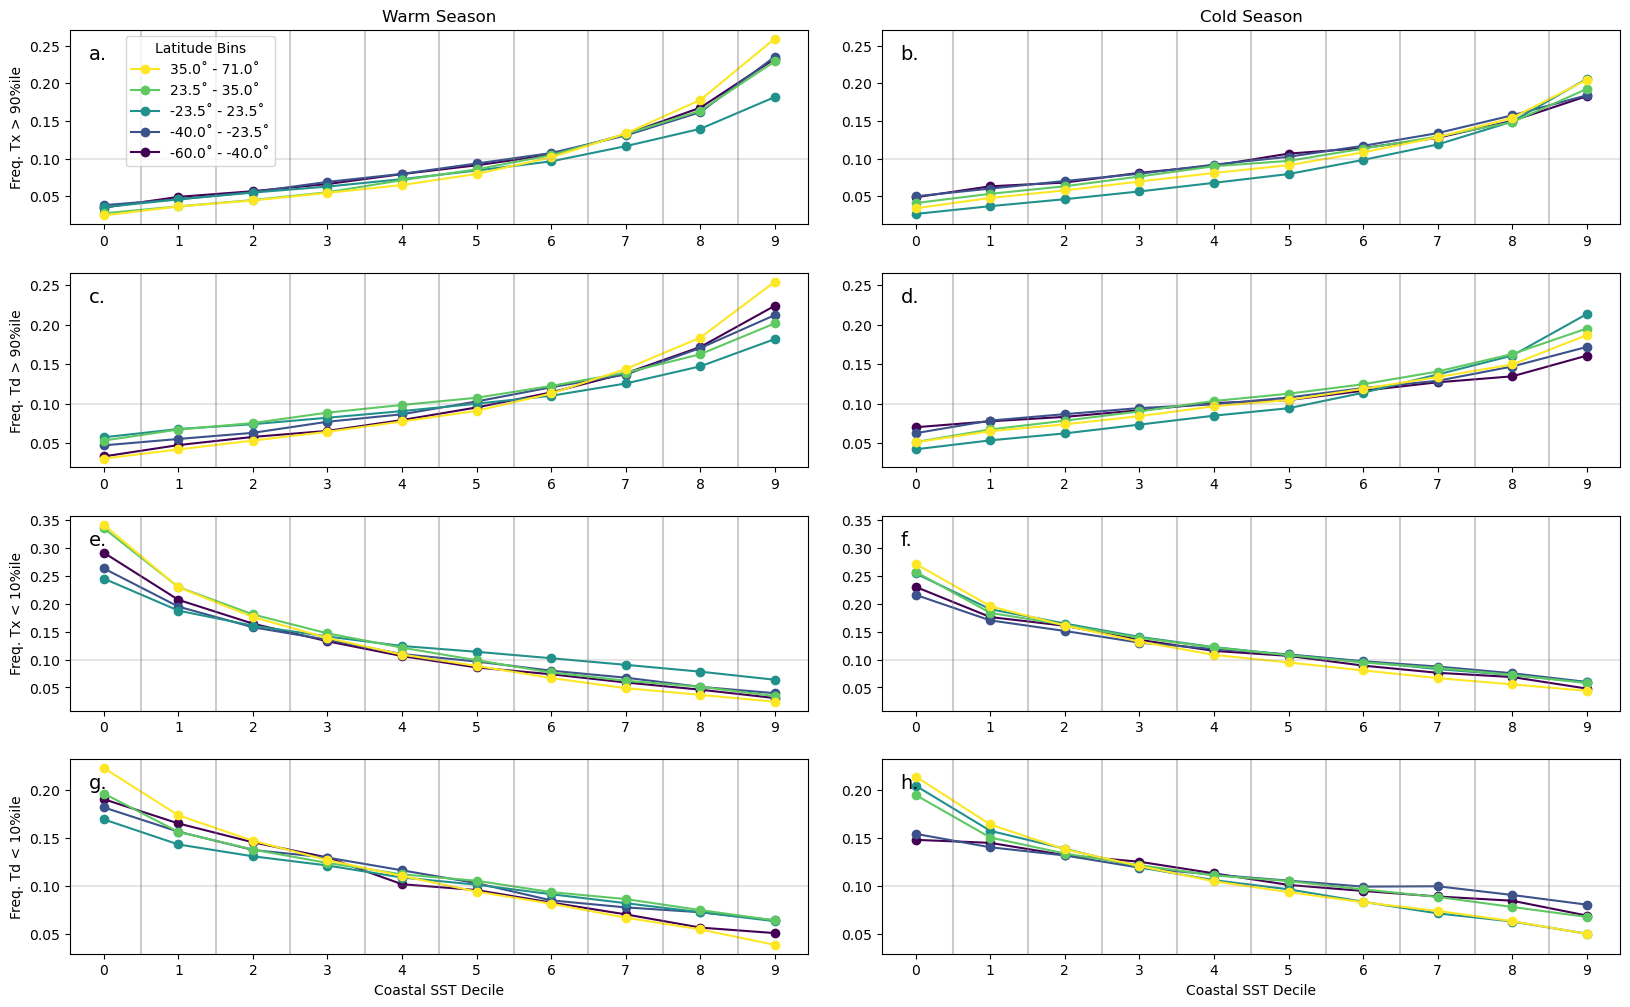

In [12]:
nrows = 4
ncols = 2
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.1, hspace=0.25)

axes = []
c_clrs = plt.get_cmap('viridis')(np.linspace(0,1,len(latbins)-1))
xs = np.array(range(10))

# list of data to plot, going r0c0, r0c1, r1c0, r1c1...
da2plot_list = [sstLATbinned_tx90_w, sstLATbinned_tx90_c, sstLATbinned_td90_w, sstLATbinned_td90_c,
               sstLATbinned_tx10_w, sstLATbinned_tx10_c, sstLATbinned_td10_w, sstLATbinned_td10_c]

varplotting_list = ['Tx > 90%ile', 'Td > 90%ile', 'Tx < 10%ile', 'Td < 10%ile']

pltctr = 0
for r in range(nrows):
    for c in range(ncols):
        
        # add subplot
        if c==0:
            ax = fig.add_subplot(gs[r,c])
        else:
            ax = fig.add_subplot(gs[r,c], sharey=axes[pltctr-1])
        
        # grab which dat I'm plotting on this subplot
        da2plot = da2plot_list[pltctr]
        
        
        for j in range(len(latbins)-1):
    
            # lat bins 
            lo_lb = latbins[j]
            hi_lb = latbins[j+1]

            # plot Tx, warm season
            ax.plot(xs, da2plot[:, j], marker='o', color=c_clrs[j], label='{}˚ - {}˚'.format(lo_lb, hi_lb))

        # ax cosmetics
        ax.set_xticks(np.arange(0, 10, 1))
        ax.set(title='', xlabel='', ylabel='')
        
        if r==(nrows-1):
            ax.set(xlabel='Coastal SST Decile')
        if c==0:
            ax.set(ylabel='Freq. {}'.format(varplotting_list[r]))

        # vertical line
        for l in np.arange(0.5, 8.6, 1):
            ax.axvline(l, color='gray', alpha=0.4)

        ax.axhline(0.1, color='grey', alpha=0.2)

            
        # done with this subplot...
        
        # update plot counting
        c+=1
        
        if c==ncols:
            r+=1
            
        pltctr += 1
        axes.append(ax)
        
        
axes[0].set(title='Warm Season')
axes[1].set(title='Cold Season')
axes[0].legend(title='Latitude Bins', reverse=True, loc=(0.075, 0.3))

## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

for i, ax in enumerate(axes):
    ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.85, transform=ax.transAxes, ha='left', fontsize=14)

## This is the one I'll use, saving as a png
# SAVE FIGURE
# plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/FigS2_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')
    
plt.show()

## Repeating this for coarser latitude bands

In [13]:
## Prepare the data -- compute the fraction of days where <terrestrial extreme event happens> conditional on SST being in a given bin -- also binned by lat. ##

latbins = np.array([-60, -30, 30, 71])

# arrays to hold output (2)
sstLATbinned_tx90_all = np.zeros(shape=(10, len(latbins)-1)) # row = sst bin, col = means for each lat bin
sstLATbinned_tx90_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx90_c = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx10_all = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx10_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_tx10_c = np.zeros(shape=(10, len(latbins)-1))

sstLATbinned_td90_all = np.zeros(shape=(10, len(latbins)-1)) # row = sst bin, col = means for each lat bin
sstLATbinned_td90_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td90_c = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td10_all = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td10_w = np.zeros(shape=(10, len(latbins)-1))
sstLATbinned_td10_c = np.zeros(shape=(10, len(latbins)-1))


# for each bin
for i in range(10):
    
    # quantiles for bin edges
    lo = sstbins[i]
    hi = sstbins[i+1]
#    print(i, sstbins[i], sstbins[i+1])
        
    # compute separate mean [frac_above_threshold] within each lat bin
    for j in range(len(latbins)-1):
        
        # lat bins and mask
        lo_lb = latbins[j]
        hi_lb = latbins[j+1]

        lat_mask = ((gdf.LAT >= lo_lb) * (gdf.LAT < hi_lb))
        
        # take mean <frac> within each lat bin and add 
        sstLATbinned_tx90_all[i,j] = np.nanmean(sstbinned_tx90_all[i,:][lat_mask])
        sstLATbinned_tx90_w[i,j] = np.nanmean(sstbinned_tx90_w[i,:][lat_mask])
        sstLATbinned_tx90_c[i,j] = np.nanmean(sstbinned_tx90_c[i,:][lat_mask])

        sstLATbinned_tx10_all[i,j] = np.nanmean(sstbinned_tx10_all[i,:][lat_mask])
        sstLATbinned_tx10_w[i,j] = np.nanmean(sstbinned_tx10_w[i,:][lat_mask])
        sstLATbinned_tx10_c[i,j] = np.nanmean(sstbinned_tx10_c[i,:][lat_mask])
        

        sstLATbinned_td90_all[i,j] = np.nanmean(sstbinned_td90_all[i,:][lat_mask])
        sstLATbinned_td90_w[i,j] = np.nanmean(sstbinned_td90_w[i,:][lat_mask])
        sstLATbinned_td90_c[i,j] = np.nanmean(sstbinned_td90_c[i,:][lat_mask])

        sstLATbinned_td10_all[i,j] = np.nanmean(sstbinned_td10_all[i,:][lat_mask])
        sstLATbinned_td10_w[i,j] = np.nanmean(sstbinned_td10_w[i,:][lat_mask])
        sstLATbinned_td10_c[i,j] = np.nanmean(sstbinned_td10_c[i,:][lat_mask])

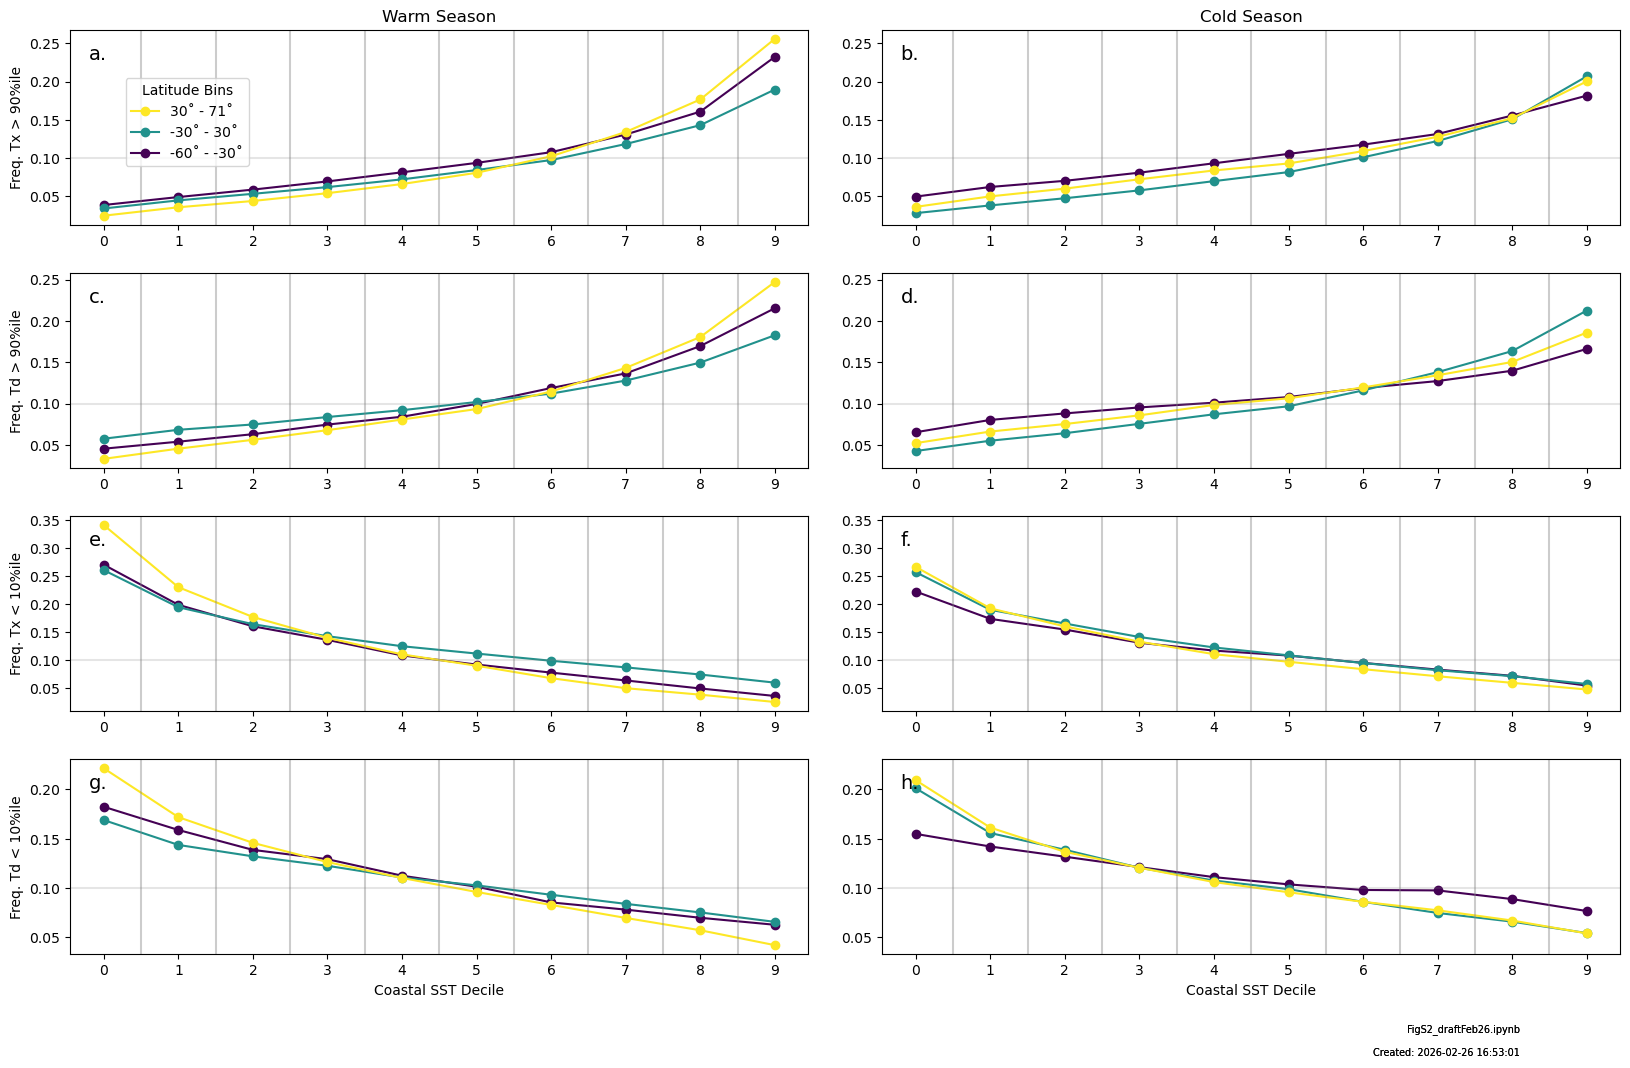

In [14]:
nrows = 4
ncols = 2
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.1, hspace=0.25)

axes = []
c_clrs = plt.get_cmap('viridis')(np.linspace(0,1,len(latbins)-1))
xs = np.array(range(10))

# list of data to plot, going r0c0, r0c1, r1c0, r1c1...
da2plot_list = [sstLATbinned_tx90_w, sstLATbinned_tx90_c, sstLATbinned_td90_w, sstLATbinned_td90_c,
               sstLATbinned_tx10_w, sstLATbinned_tx10_c, sstLATbinned_td10_w, sstLATbinned_td10_c]

varplotting_list = ['Tx > 90%ile', 'Td > 90%ile', 'Tx < 10%ile', 'Td < 10%ile']

pltctr = 0
for r in range(nrows):
    for c in range(ncols):
        
        # add subplot
        if c==0:
            ax = fig.add_subplot(gs[r,c])
        else:
            ax = fig.add_subplot(gs[r,c], sharey=axes[pltctr-1])
        
        # grab which dat I'm plotting on this subplot
        da2plot = da2plot_list[pltctr]
        
        
        for j in range(len(latbins)-1):
    
            # lat bins 
            lo_lb = latbins[j]
            hi_lb = latbins[j+1]

            # plot Tx, warm season
            ax.plot(xs, da2plot[:, j], marker='o', color=c_clrs[j], label='{}˚ - {}˚'.format(lo_lb, hi_lb))

        # ax cosmetics
        ax.set_xticks(np.arange(0, 10, 1))
        ax.set(title='', xlabel='', ylabel='')
        
        if r==(nrows-1):
            ax.set(xlabel='Coastal SST Decile')
        if c==0:
            ax.set(ylabel='Freq. {}'.format(varplotting_list[r]))

        # vertical line
        for l in np.arange(0.5, 8.6, 1):
            ax.axvline(l, color='gray', alpha=0.4)

        ax.axhline(0.1, color='grey', alpha=0.2)

            
        # done with this subplot...
        
        # update plot counting
        c+=1
        
        if c==ncols:
            r+=1
            
        pltctr += 1
        axes.append(ax)
        
        
axes[0].set(title='Warm Season')
axes[1].set(title='Cold Season')
axes[0].legend(title='Latitude Bins', reverse=True, loc=(0.075, 0.3))

## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

for i, ax in enumerate(axes):
    ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.85, transform=ax.transAxes, ha='left', fontsize=14)

now = datetime.now() # get datetime
fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')

now = datetime.now() # get datetime
fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')

    
plt.show()